# Notebook to demo trip duration statistics.

In [1]:
import os
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F
import pyspark.sql.types as T
import xyzservices.providers as xyz

In [2]:
schema = ",".join(
    [
        "`id` string",
        "`vendor_id` string",
        "`pickup_datetime` timestamp",
        "`dropoff_datetime` timestamp",
        "`passenger_count` integer",
        "`pickup_longitude` double",
        "`pickup_latitude` double",
        "`dropoff_longitude` double",
        "`dropoff_latitude` double",
        "`store_and_fwd_flag` string",
        "`trip_duration` integer",
    ]
)

In [3]:
csv_path = os.path.expanduser("~/JHUBigDataClass/data/nyc-taxi-trip-duration/train.csv")
df = spark.read.csv(csv_path, header=True, schema=schema)

In [4]:
df.count()

1458644

In [5]:
trip_dur = df.select("trip_duration").filter("trip_duration < 4000")

+-------+-----------------+
|summary|    trip_duration|
+-------+-----------------+
|  count|          1450346|
|   mean|819.9496568405057|
| stddev|604.6405939146398|
|    min|                1|
|    max|             3999|
+-------+-----------------+



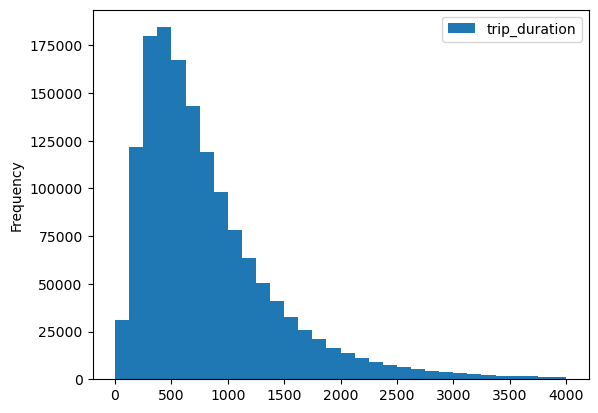

In [6]:
trip_dur.describe().show()
trip_dur.toPandas().plot.hist(bins=32);